# LAB08

## Esercizio 8.1

#### INTRODUZIONE
In meccanica quantistica, il principio variazionale afferma che il valore di aspettazione dell’Hamiltoniana calcolato su una qualsiasi funzione d’onda di prova $\Psi_T$ è sempre maggiore o uguale all’energia del ground state $E_0$: 

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

Questo principio permette di stimare numericamente l’energia fondamentale scegliendo una funzione d’onda dipendente da parametri liberi e minimizzando il valore di aspettazione dell’energia rispetto a tali parametri.

In questo caso, si consideri una quantistica in una dimensione soggetta al potenziale:
$$ V(x) = x^4 - \frac{5}{2} x^2 $$
Questo potenziale presenta una struttura a doppia buca, quindi ci si aspetta che lo stato fondamentale sia distribuito su due regioni simmetriche. Per descrivere il sistema utilizziamo una funzione di prova del tipo:

$$ \Psi_T ^{\sigma, \mu} (x) = e^{-\frac{(x-\mu)^2}{2 \sigma^2}} + e^{-\frac{(x+\mu)^2}{2 \sigma^2}}$$

Questa scelta è ben motivata dal fatto che è simmetrica e rappresenta bene una doppia localizzazione; inoltre, dipende da due parametri variazionali, ovvero $\sigma$ (larghezza delle gaussiane) e $\mu$ (posizione dei massimi). 

#### CALCOLO DELL'ENERGIA
L'energia media può essere scritta come: 

$$ \braket{H}_T = \int dx \, p(x) E_{loc}(x)$$

dove $p(x)= |\Psi(x)|^2$ è la distribuzione di probabilità, mentre $E_{loc}(x)$ è l'energia locale, data da: 

$$ E_{loc} = - \frac{1}{2} \frac{\Psi''(x)}{\Psi(x)} + V(x)$$

Si utilizza $\hbar =1$ e $m=1$. Per calcolare l'integrale, si utilizza il metodo *Variational Monte Carlo*: si campionano punti distribuiti come $p(x)= |\Psi(x)|^2$, si calcola l'energia locale per ciascun punto e si fa la media tramite il metodo di data blocking. 

#### ALGORITMO DI METROPOLIS
Il campionamento viene effettuato tramite algoritmo di Metropolis, che funziona nel seguente modo: 
- Si parte da una certa posizione $x_0$
- Viene proposta una nuova posizione $x_{new}=x_{old} + \delta$, dove $\delta$ è un numero casuale nell'intervallo $[-\Delta, \Delta]$
- Si calcola la probabilità di accettazione: $A = min (1, \frac{|\Psi(x_{new})|^2}{|\Psi(x_{old})|^2})$. Se $|\Psi(x_{new})|^2 > |\Psi(x_{old})|^2$, allora $A=1$ e quindi la mossa viene sempre accettata; viceversa, se $A<1$ la mossa viene accettata con probabilità $A$.
- Viene infine generato un numero casuale $r$ in $[0,1]$: se $r<A$, la mossa viene accettata ($x=x_{new}$), altrimenti viene rifiutata ($x=x_{old}$).

#### DETERMINAZIONE DI $\Delta$ E GRAFICI FINALI
Per questa simulazione si fissano i seguenti parametri: $\sigma=0.5$ e $\mu=1.2$. Questi parametri rappresentano un'approssimazione del ground state: ci aspettiamo quindi un'energia vicina al minimo (stimato essere circa $-0.46$) ma non esattamente precisa. 

Innanzitutto, per il corretto funzionamento dell'algoritmo di Metropolis è necessario determinare $\Delta$, ovvero l'estremo dell'intervallo $[-\Delta, \Delta]$ da cui estrarre $\delta$. Si cerca dunque un $\Delta$ che renda l'acceptance rate pari al 50%: facendo un po' di prove, si conclude che $\Delta = 1.1001$. 

Viene poi implementato il data blocking con un numero torale di passi $M= 10^5$ e un numero di blocchi $N=100$. A seguito di un'equilibrazione di 20000 passi, viene prodotto il seguente grafico dell'energia media in funzione dei blocchi. L'energia media mostra una chiara convergenza al crescere del numero di blocchi, anche se non esattamente al valore del minimo di energia pari a $-0.46$: come già anticipato, questo mostra come i parametri scelti $\sigma=0.5$ e $\mu=1.2$ sono un'approssimazione del ground state e non il minimo esatto. Il valore di convergenza trovato è comunque maggiore del minimo dell'energia: è così rispettato il pirncipio variazionale. Nel prossimo esercizio verranno identificati dei valori dei parametri che approssimano meglio il ground state. 

Inoltre, viene riportato il grafico dell'errore statistico in funzione dei blocchi: questo assume il caratteristico andamento $\frac{1}{\sqrt{N}}$ (come previsto dal teorema del limite centrale). 

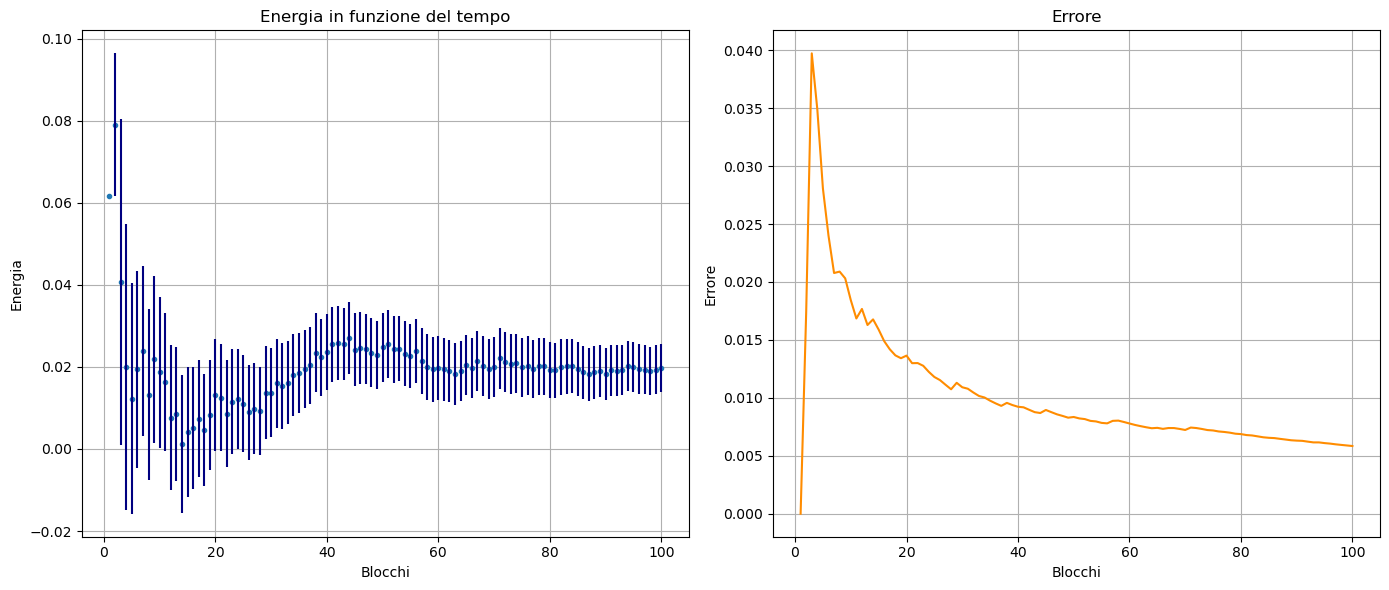

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("esercizio8.1/data.dat")

blk = data[:, 0]
energia = data[:, 1]
error = data[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(blk, energia, ".")
axes[0].errorbar(blk, energia, yerr=error, color="navy", linestyle="none")
axes[0].set_xlabel("Blocchi")
axes[0].set_ylabel("Energia")
axes[0].set_title("Energia in funzione del tempo")
axes[0].grid(True)

# PLOT ERRORE
axes[1].errorbar(blk, error, marker='', linestyle='-', color='darkorange')
axes[1].set_xlabel("Blocchi")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## COSA HO FATTO
Inizialmente ho definito le funzioni psi, psi_der2, pot e local_energy, dove local energy è $E_{loc}(x) = -\frac{1}{2} \frac{\Psi''(x)}{\Psi(x)}+V(x)$

poi scrivo la funzione per il metropolis: 
Il metropolis è un algoritmo che general numeri casuali non unifpormi distribuiti come voglio io. Nel nostro caso vogliamo ca,pionare $| \Phi(x)$. funziona in questo modo: 
- parto da un punto iniziale
- propongo un punto vicino: xnew = xold + delta (dove delta è casuale unifome tra -Delta e +Delta)
- calcolo a probabilità di accettazione: $A = min (1, \frac{|\Psi(x_{new})|^2}{|\Psi(x_{old})|^2})$. Se $|\Psi(x_{new})|^2 > |\Psi(x_{old})|^2$ allora $A=1$: quindi accetto sempre. Viceversa, se $A<1$ accetto con probabilità $A$.
- genero un numero casuale $r$ tra 0 e 1: se $r<A$ accetto (quindi x=xnew), se no rifiuto (x=xold).
Dunque, dopo tanti passi i valori di x saranno distribuiti come $|\Psi(x)|^2$


Poi sono passata a determinare il Delta che fa sì che ho un accreptance rate del 50%. Facendo un po' di prove arrivo alla conclusione che Delta=1.0005. 

poi ho imolementato il data blocking

# TEORIA

Principio variazionale: costriuisco una famiglia di funzioni dipendenti da una serie di  parametri e prendo il vettore di parametri che minimizza E. 
Hp un integrale da calcolare: applico il metropolis -> Variational Montecarlo 

algoritmi basati sui gradienti: sono molto efficienti nel determonare il punto mìdi minimo locale più vicino al punto di partenza. non è il top perchè potrebbe essere un minimo locale e non globale. La soluzione è provare a partiore da punti diversi e tenere il migliore ottenuto. 
poi ci sono i metodi euristici e stocatici: ci concentriamo su questi

altra distinzione: 
- trajectory based: c'è un solo agente che percorre una traiettoria
- popularion based: ci sono più agenti che ognuno fa la prorpia traiettoria. può esseci correlazione tra gli agenti oppure no.

algoritmi ibridi


## Esercizio 8.2

In questo esercizio si vuole determinare i parametri $\sigma$ e $\mu$ che vanno a minimizzare $\braket{\hat{H}}_T$, ovvero l'energia media calcolata con la funzione d'onda trial. 

#### ALGORITMO DI SIMULATED ANNEALING (SA)
Per questa ottimizzazione viene utilizzato l'algoritmo di Simulated Annealing, che simula un sistema termodinamico fittizio in cui ad alta temperatura il sistema esplora liberamente lo spazio dei parametri e 
a bassa temperatura si “congela” attorno ai minimi energetici. Ad ogni passo, si parte da un set di parametri $(\sigma, \mu)$ e vengono proposti dei nuovi parametri  $(\sigma', \mu')$; a questo punto si calcolano le energie associate $E_{old}$ ed $E_{new}$ e si accetta la mossa con probabilità $P=min(1, e^{-\beta(E_{new}-E_{old})})$, dove $\beta = \frac{1}{T}$. 

La temperatura viene ridotta progressivamente. Per temperature alte, si ha una fase di esplorazione globale, dato che vengono accettati anche peggioramenti energetici; invece, per temperature basse si ha la convergenza al minimo dell'energia, poiché si accettano solo miglioramenti. Dunque, la temperatura contolla il passaggio da esplorazione ad ottimizzazione: in questo modo il sistema evita minimi locali non ottimali. 

#### STRUTTURA DEL CODICE
L'esercizio viene separato in due file: `ottimizzazione.cpp` e `esercizio8.2.cpp`. 

Il file `ottimizzazione.cpp` si occupa di trovare i parametri ottimali $\mu$ e $\sigma$ e sfrutta l'algoritmo SA. Gli output prodotti sono i seguenti: 
- `optimal.dat`: contiene i parametri $\mu$ e $\sigma$ e verrà poi letto nel secondo file.
- `SA_energy.dat`: contiene l'energia in funzione dei passi SA e serve per mostrare la convergenza del processo.
- `SA_param.dat`: contiene i valori di $\mu$ e $\sigma$ ad ognu step; serve per visualizzare la traiettoria nello spazio dei parametri.

Una volta ottenuti i parametri ottimali $\sigma$ e $\mu$, si esegue una simulzione VMC standard tramite `esercizio8.2.cpp`. Di fatto questo file coincide con il codice scritto per l'esercizio 8.1, con la differenza che legge da file i parametri ottenuti tramite l'ottimizzazione precedente. Prima della simulazione, viene ricalibrato il passo del Metripolis $\Delta$ al fine di mantenere un'accettanza di circa 50%: si ottiene $\Delta=2.635$. Durante la simulazone, si verifica che l'accettanza resti stabile attorno al 50%; ciò viene mostrato nel seguente grafico. 

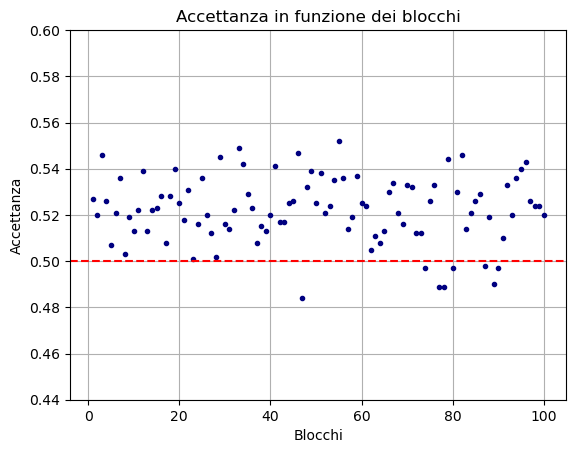

In [67]:
import numpy as np
import matplotlib.pyplot as plt

data_acc = np.loadtxt("esercizio8.2/OUTPUT/acc.dat")
blk = data_acc[:, 0]
acc = data_acc[:, 1]


plt.plot(blk, acc, ".", color='navy')
plt.xlabel("Blocchi")
plt.ylabel("Accettanza")
plt.title("Accettanza in funzione dei blocchi")
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5)
plt.grid(True)
plt.ylim(0.44, 0.60)

plt.show()

#### GRAFICI DI OUTPUT
Innanzitutto, viene plottata l'energia in funzione dei passi del SA: l'andamento egenrale mostra chiaramente un comportamento di convergenza. Nella fase iniziale, caratterizzata da temperature elevate, l’energia presenta ampie fluttuazioni: questo è dovuto al fatto che vengono accettate anche mosse energeticamente sfavorevoli, permettendo un’esplorazione globale dello spazio dei parametri. Riducendo progressivamente la temperatura, la probabilità di accettare configurazioni peggiori diminuisce e il sistema tende a spostarsi verso regioni a energia più bassa. Nella fase finale, a basse temperature, l’energia si stabilizza attorno a un valore minimo, indicando che l’algoritmo ha individuato un insieme ottimale di parametri variazionali.

Accanto viene riportato un grafico che mostra la traiettoria nello spazioni dei parametri $(\sigma, \mu)$: ciò rappresenta l’evoluzione dei parametri variazionali durante il processo di Simulated Annealing. Nella fase iniziale, a temperatura elevata, i punti risultano distribuiti su una regione ampia dello spazio dei parametri, evidenziando un’esplorazione globale che consente di evitare minimi locali. Man mano che la temperatura diminuisce, la traiettoria si concentra progressivamente in una regione più ristretta, segnalando la convergenza verso una valle di energia minima. Nella fase finale, i punti risultano fortemente addensati attorno a una zona ben definita, corrispondente al minimo dell’energia variazionale.

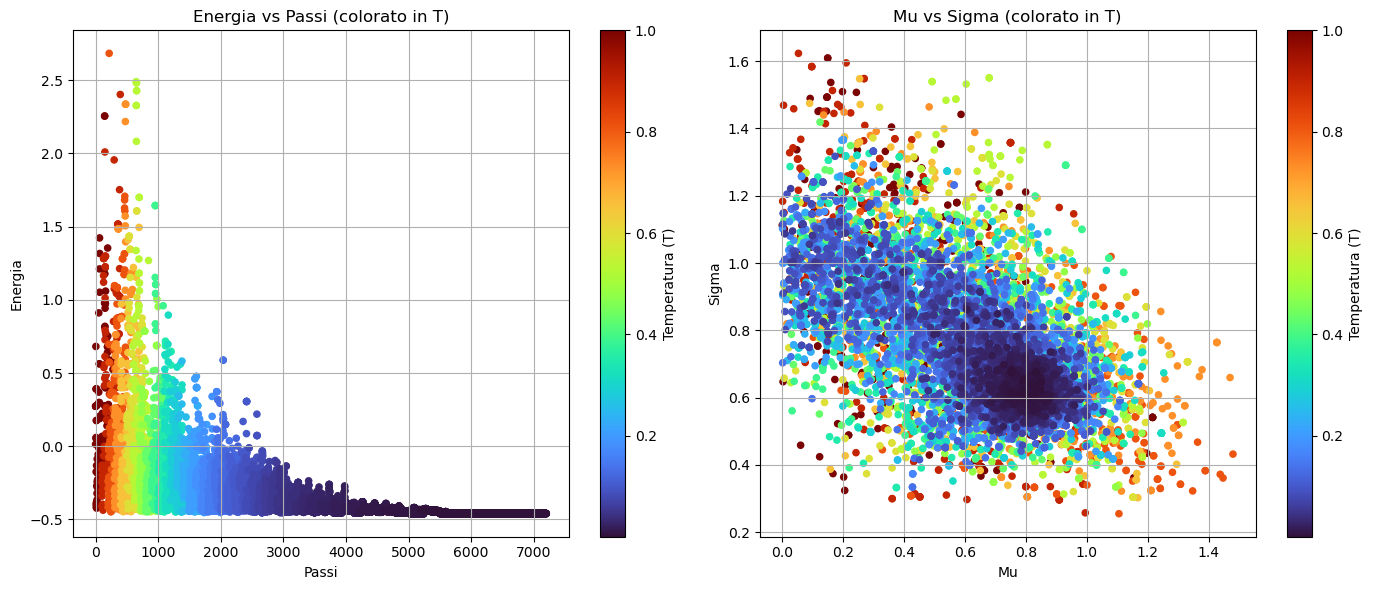

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Caricamento dati
energy = np.loadtxt("esercizio8.2/OUTPUT/SA_energy.dat")
param  = np.loadtxt("esercizio8.2/OUTPUT/SA_param.dat")

passi = energy[:, 0]
beta_energy = energy[:, 1]
energia = energy[:, 2]

beta_param = param[:, 1]
mu = param[:, 2]
sigma = param[:, 3]

T_energy = 1 / beta_energy
T_param  = 1 / beta_param

# Normalizzazione comune
T_min = min(T_energy.min(), T_param.min())
T_max = max(T_energy.max(), T_param.max())
norm = mcolors.Normalize(vmin=T_min, vmax=T_max)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Energia vs Passi ----
sc0 = axes[0].scatter(passi, energia, c=T_energy, cmap="turbo", norm=norm, s=20)
axes[0].set_xlabel("Passi")
axes[0].set_ylabel("Energia")
axes[0].set_title("Energia vs Passi (colorato in T)")
axes[0].grid(True)

cbar0 = plt.colorbar(sc0, ax=axes[0])
cbar0.set_label("Temperatura (T)")

# ---- Mu vs Sigma ----
sc1 = axes[1].scatter(mu, sigma, c=T_param, cmap="turbo", norm=norm, s=20)
axes[1].set_xlabel("Mu")
axes[1].set_ylabel("Sigma")
axes[1].set_title("Mu vs Sigma (colorato in T)")
axes[1].grid(True)

cbar1 = plt.colorbar(sc1, ax=axes[1])
cbar1.set_label("Temperatura (T)")

plt.tight_layout()
plt.show()

Una volta determinati i parametri ottimali, che risultano essere $\mu=0.821184$ e $\sigma=0.638538$, si esegue una simulazione VMC standard come nell'esercizio 8.1. 

Il grafico dell’energia in funzione del numero di blocchi mostra una chiara convergenza. Nelle prime fasi si osservano fluttuazioni più ampie dovute alla limitata statistica, mentre aumentando il numero di blocchi la media cumulativa si stabilizza progressivamente. Nella parte finale del grafico l’energia oscilla attorno a un valore costante, con incertezze statistiche ridotte, indicando che la simulazione ha raggiunto una stima affidabile del valore medio dell’energia. Le barre di errore, calcolate tramite il metodo del data blocking, risultano compatibili con le fluttuazioni osservate e decrescono all’aumentare della statistica con il tipico andamento $\propto \frac{1}{\sqrt{N}}$. 

Il valore di convergenza dell'energia all'aumentare dei blocchi viene confrontato con il valore ottenuto dalla soluzione matriciale fornita nella sezione supplementare della consegna (tratteggiato in rosso). I due valori non sono statisticamente compatibili, per cui probabilmente lo stato trovato non è il vero stato fondamentale ma solo una sua approssimazione. 

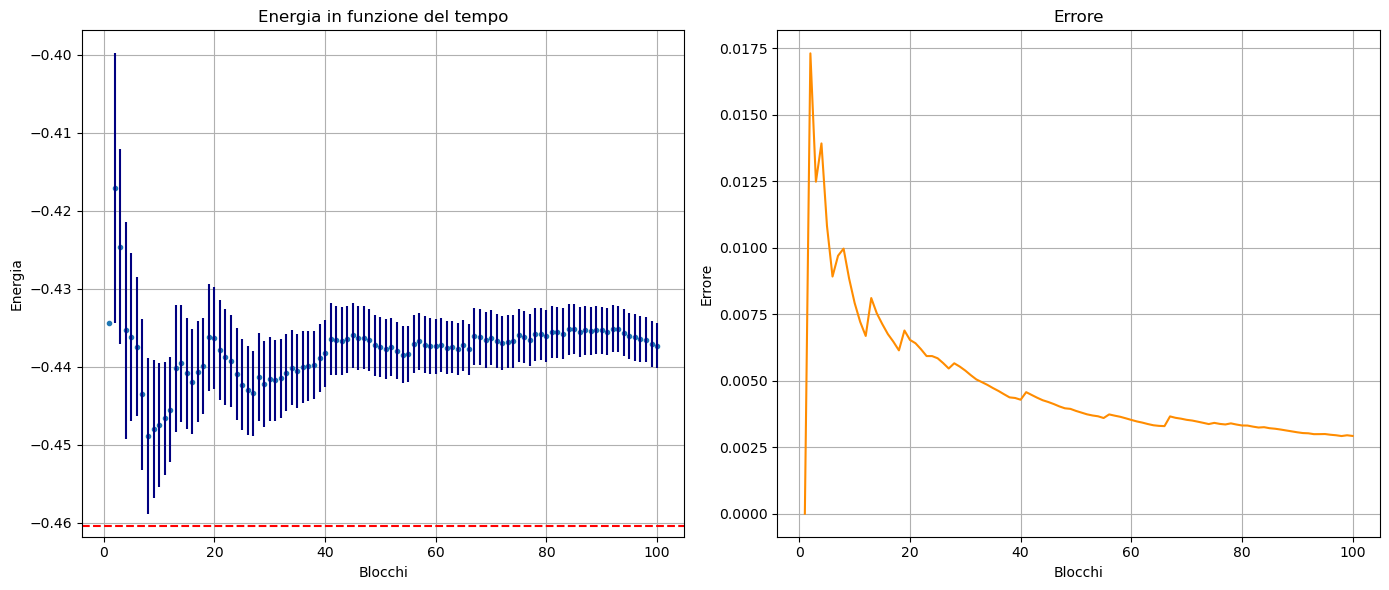

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("esercizio8.2/OUTPUT/data.dat")


blk = data[:, 0]
energia = data[:, 1]
error = data[:, 2]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(blk, energia, ".")
axes[0].errorbar(blk, energia, yerr=error, color="navy", linestyle="none")
axes[0].set_xlabel("Blocchi")
axes[0].set_ylabel("Energia")
axes[0].set_title("Energia in funzione del tempo")
axes[0].axhline(y=-0.46046, color='red', linestyle='--', linewidth=1.5, label='Matrice')
axes[0].grid(True)

# PLOT ERRORE
axes[1].errorbar(blk, error, marker='', linestyle='-', color='darkorange')
axes[1].set_xlabel("Blocchi")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)
plt.tight_layout()
plt.show()



Infine, viene realizzato un istogramma delle posizioni campionate tramite algoritmo di Metropolis che rappresenta una stima numerica della densità di probabilità $|\Psi_T(x)^2|$. Si osserva una chiara struttura a due picchi simmetrici, coerente con la forma della funzione d’onda trial utilizzata. Il confronto con la curva analitica mostra un ottimo accordo, indicando che il campionamento Monte Carlo riproduce correttamente la distribuzione di probabilità del sistema.

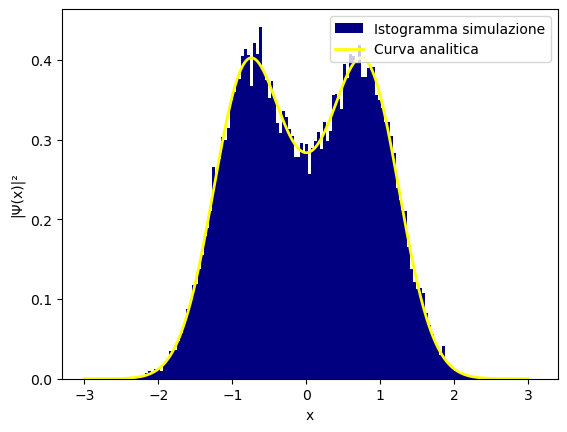

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# LETTURA SIGMA E MU
with open("esercizio8.2/OUTPUT/optimal.dat", "r") as f:
    mu = float(f.readline())
    sigma = float(f.readline())

# CARICAMENTO ISTOGRAMMA
data = np.loadtxt("esercizio8.2/OUTPUT/histo.dat")

# CURVA ANALITICA
def psi(x, mu, sigma):
    return np.exp(-(x-mu)**2/(2*sigma**2)) + np.exp(-(x+mu)**2/(2*sigma**2))
x = np.linspace(-3, 3, 1000)
y = psi(x, mu, sigma)**2
y /= np.trapezoid(y, x) # normalizzazione numerica

# PLOT
plt.hist(data, bins=150, density=True, color='navy', label="Istogramma simulazione",)
plt.plot(x, y, label="Curva analitica", linewidth=2, color ='yellow')

plt.xlabel("x")
plt.ylabel("|Ψ(x)|²")
plt.legend()
plt.show()

### QUESTIONI APERTE
- quanti step per ogni temperatura? il numero è fisso p dipende dalla temperatura stessa?
- forse sono troppi punti
- plottare grafico matrici prof

## COSA HO FATTO

Vogliamo ora trovare i parametri $\sigma$ e $\mu$ che vanno a minimizzare $\braket{\hat{H}}_T$, ovvero l'energia media calcolata con la mia funzione d'onda trial. 

dobbiam usare il simulated annealing
- parto da $(\sigma, \mu)$ e propongo dei nuovi parametri $(\sigma', \mu')$
- calcolo $E_{old}$ e $E_{new}$
- accetto con probabilità $P=min(1, e^{-\beta(E_{new}-E{old})})


ho diviso il codice in due file: 
- ottimizzazione.cpp : si occupa di determinare o parametri che meglio approssimano il ground state. stampa su un file i valori ottimali di sigma e mu. 
- esercizio8.2: è di fatto 8.1 ma legge sigma e mu dal file `optimal.dat`.

ottimizzazione.cpp: 
nel codice per prima cosa ho scritto la funzione `double ave_energy(double mu, double sigma, Random &rnd)`: serve per il calcolo dell'energia da usare in SA. è di fatto il data blocking del 8.1, ma calcola solo l'energia finale (no errori, no stampa su file). Il Delta lo tengo fisso. 
poi nel main c'è l'algoritmo SA che permette di calcolare sigma e mu ottimali, che vengono stampati sul file `optimal.dat`. questo file produce anche altri due file di output:
- SA_energy: rappresenta l'energia stimata del ground state in funzione dei passi
- SA_energy: stampa mu e sigma ad ogni passo. da qui faccio il grafico della traiettoria del piano mu-sigma


esercizio8.2.cpp: 
una volta che ho i parametri ottimali ho ricalcolato il Delta in modo da avere un acceptance rate di 50%: ottendo Delta = 2.635. ad ogno blocco poi controllo che l'accettanza sia sempre attorno al 50% (grafico sotto). 
in questo file stampo anche tutte le posizione estratte con il metropolis: mi servono per fare l'istogramma (che faccio in Python). 



